<a href="https://colab.research.google.com/github/pushpakgaidhane294/NNDL_lab/blob/main/Practical_8_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# CELL 1: Install and Import Required Libraries
# ============================================================

!pip -q install scikit-learn pandas numpy matplotlib seaborn

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [6]:
# ============================================================
# CELL 2: Load MNIST Dataset
# ============================================================

DATA_HOME = "/content/sklearn_data"

print("Downloading/loading MNIST...")
print("The first run may take some time.")

mnist = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False,
    data_home=DATA_HOME,
    parser="auto"
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print("\nDataset loaded successfully.")
print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))

Downloading/loading MNIST...
The first run may take some time.

Dataset loaded successfully.
Dataset shape: (70000, 784)
Number of features: 784
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


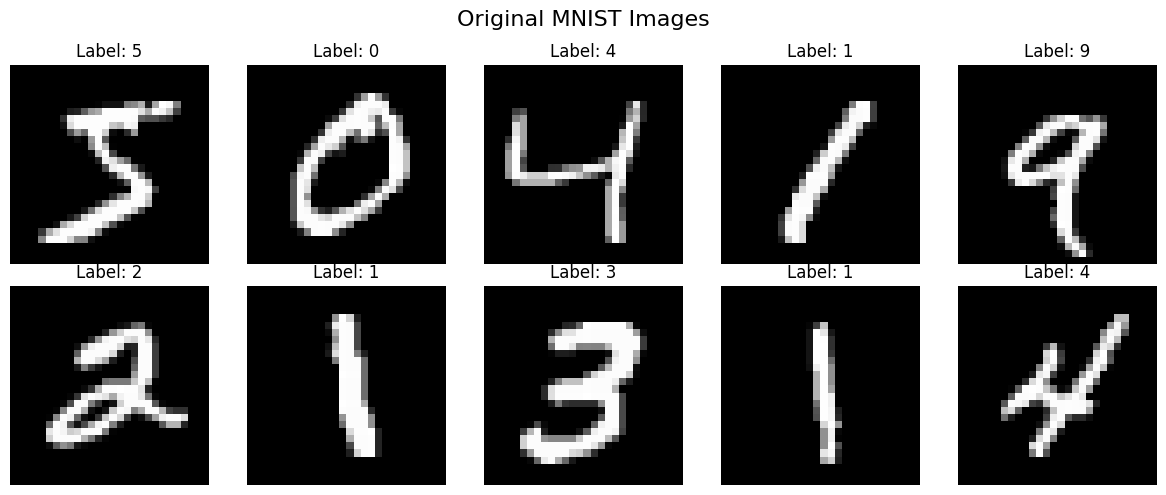

In [7]:
# ============================================================
# CELL 3: Visualize Original MNIST Images
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        X[i].reshape(28, 28),
        cmap="gray"
    )
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.suptitle(
    "Original MNIST Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 4: Split Dataset into Training and Testing Sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (56000, 784)
Testing data : (14000, 784)


In [9]:
# ============================================================
# CELL 5: Standardize the Features
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

print("\nTraining mean:")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("\nTraining standard deviation:")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))

Standardization completed.

Training mean:
[0. 0. 0. 0. 0.]

Training standard deviation:
[0. 0. 0. 0. 0.]


In [10]:
# ============================================================
# CELL 6: Apply PCA
# ============================================================

print("Fitting PCA...")

start_time = time.time()

pca_full = PCA(
    n_components=None,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)

pca_time = time.time() - start_time

print(f"PCA completed in {pca_time:.2f} seconds.")

print("Original dimensions:",
      X_train_scaled.shape[1])

print("PCA dimensions:",
      X_train_pca_full.shape[1])

Fitting PCA...
PCA completed in 32.57 seconds.
Original dimensions: 784
PCA dimensions: 784


In [11]:
# ============================================================
# CELL 7: Analyze Explained Variance
# ============================================================

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

variance_targets = [
    0.80,
    0.90,
    0.95,
    0.99
]

print("Number of components required:")
print("-" * 45)

for target in variance_targets:

    n_components = (
        np.argmax(
            cumulative_variance >= target
        ) + 1
    )

    print(
        f"{target * 100:.0f}% variance: "
        f"{n_components} components"
    )

Number of components required:
---------------------------------------------
80% variance: 149 components
90% variance: 237 components
95% variance: 330 components
99% variance: 542 components


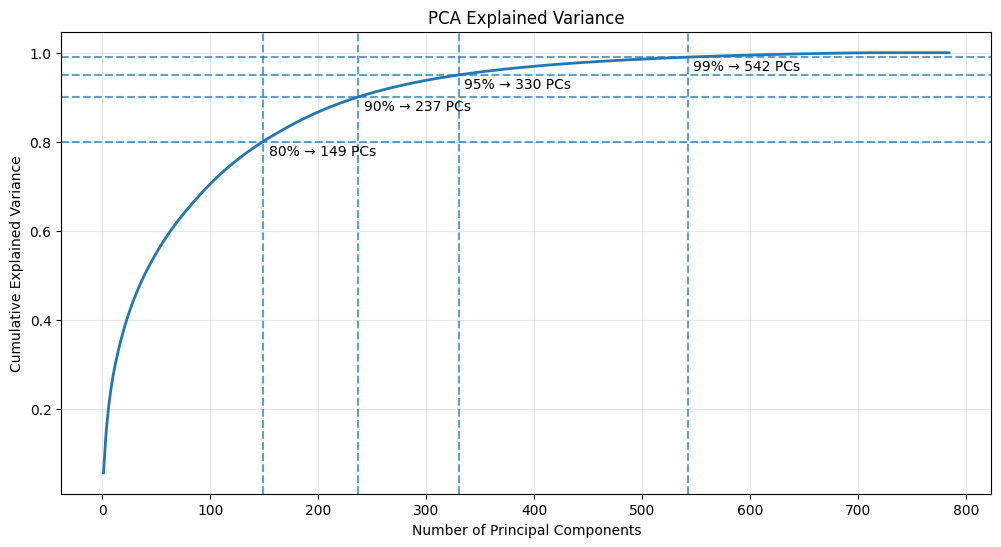

In [12]:
# ============================================================
# CELL 8: Plot Cumulative Explained Variance
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    linewidth=2
)

for target in variance_targets:

    n_components = (
        np.argmax(
            cumulative_variance >= target
        ) + 1
    )

    plt.axhline(
        target,
        linestyle="--",
        alpha=0.7
    )

    plt.axvline(
        n_components,
        linestyle="--",
        alpha=0.7
    )

    plt.text(
        n_components + 5,
        target - 0.03,
        f"{target * 100:.0f}% → {n_components} PCs"
    )

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Explained Variance"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [13]:
# ============================================================
# CELL 9: Select Components for 95% Variance
# ============================================================

TARGET_VARIANCE = 0.95

N_COMPONENTS = (
    np.argmax(
        cumulative_variance >= TARGET_VARIANCE
    ) + 1
)

retained_variance = (
    cumulative_variance[N_COMPONENTS - 1]
)

dimension_reduction = (
    1 -
    N_COMPONENTS /
    X_train_scaled.shape[1]
) * 100

compression_ratio = (
    X_train_scaled.shape[1] /
    N_COMPONENTS
)

print("PCA Dimensionality Reduction")
print("-" * 40)

print(
    "Original features:",
    X_train_scaled.shape[1]
)

print(
    "Selected components:",
    N_COMPONENTS
)

print(
    f"Retained variance: "
    f"{retained_variance * 100:.2f}%"
)

print(
    f"Dimensionality reduction: "
    f"{dimension_reduction:.2f}%"
)

print(
    f"Compression ratio: "
    f"{compression_ratio:.2f}x"
)

PCA Dimensionality Reduction
----------------------------------------
Original features: 784
Selected components: 330
Retained variance: 95.01%
Dimensionality reduction: 57.91%
Compression ratio: 2.38x


In [14]:
# ============================================================
# CELL 10: Transform Data using Selected PCA Components
# ============================================================

pca = PCA(
    n_components=N_COMPONENTS,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print("Before PCA:")
print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

print("\nAfter PCA:")
print("Train:", X_train_pca.shape)
print("Test :", X_test_pca.shape)

Before PCA:
Train: (56000, 784)
Test : (14000, 784)

After PCA:
Train: (56000, 330)
Test : (14000, 330)


In [15]:
# ============================================================
# CELL 11: PCA Reconstruction
# ============================================================

X_test_reconstructed_scaled = (
    pca.inverse_transform(
        X_test_pca
    )
)

X_test_reconstructed = (
    scaler.inverse_transform(
        X_test_reconstructed_scaled
    )
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "PCA representation:",
    X_test_pca.shape
)

print(
    "Reconstructed shape:",
    X_test_reconstructed.shape
)

Original test shape: (14000, 784)
PCA representation: (14000, 330)
Reconstructed shape: (14000, 784)


In [16]:
# ============================================================
# CELL 12: Calculate Reconstruction Error
# ============================================================

mse = mean_squared_error(
    X_test_scaled,
    X_test_reconstructed_scaled
)

rmse = np.sqrt(mse)

print("PCA Reconstruction Error")
print("-" * 35)

print(
    f"Mean Squared Error  : {mse:.6f}"
)

print(
    f"Root Mean Squared Error: {rmse:.6f}"
)

PCA Reconstruction Error
-----------------------------------
Mean Squared Error  : 0.425057
Root Mean Squared Error: 0.651964


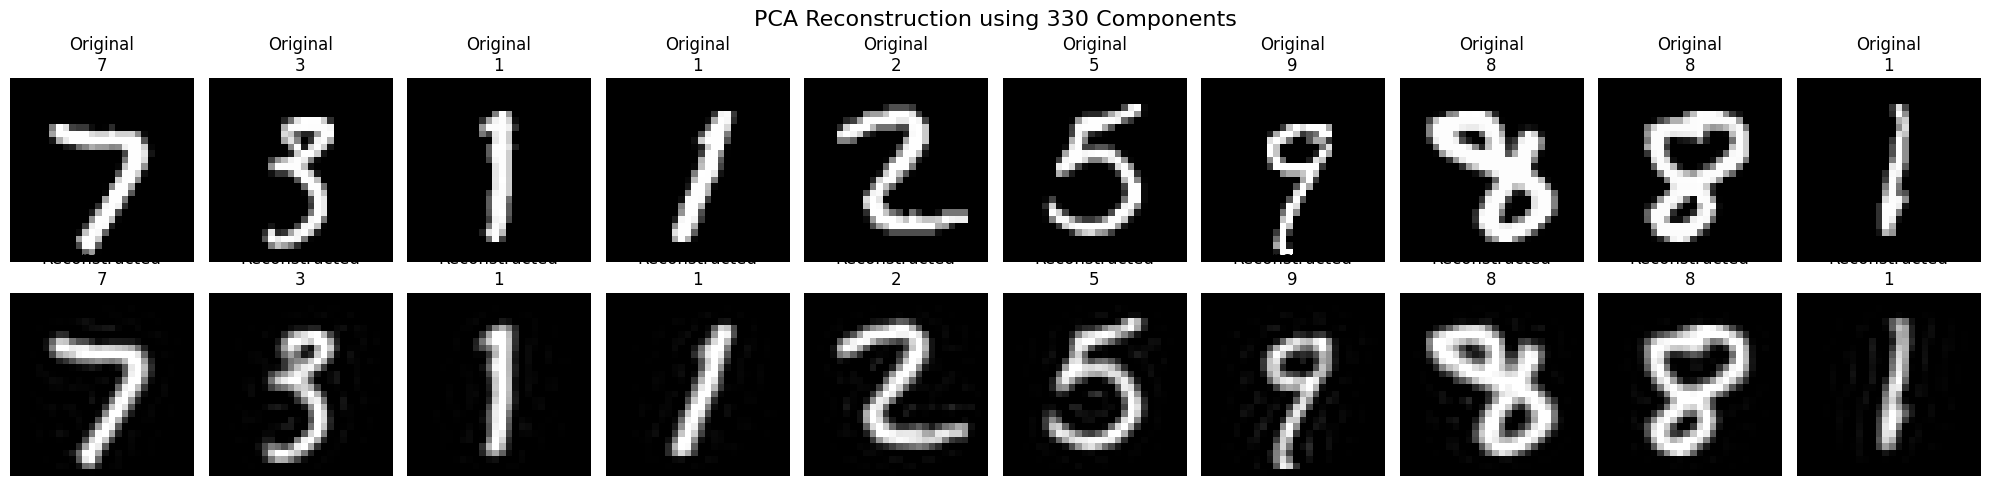

In [17]:
# ============================================================
# CELL 13: Original vs Reconstructed Images
# ============================================================

n_images = 10

fig, axes = plt.subplots(
    2,
    n_images,
    figsize=(20, 5)
)

for i in range(n_images):

    # Original image
    axes[0, i].imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    axes[0, i].set_title(
        f"Original\n{y_test[i]}"
    )

    axes[0, i].axis("off")

    # Reconstructed image
    reconstructed = np.clip(
        X_test_reconstructed[i],
        0,
        255
    )

    axes[1, i].imshow(
        reconstructed.reshape(28, 28),
        cmap="gray"
    )

    axes[1, i].set_title(
        f"Reconstructed\n{y_test[i]}"
    )

    axes[1, i].axis("off")

axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PCA Reconstruction",
    fontsize=12
)

plt.suptitle(
    f"PCA Reconstruction using {N_COMPONENTS} Components",
    fontsize=16
)

plt.tight_layout()
plt.show()

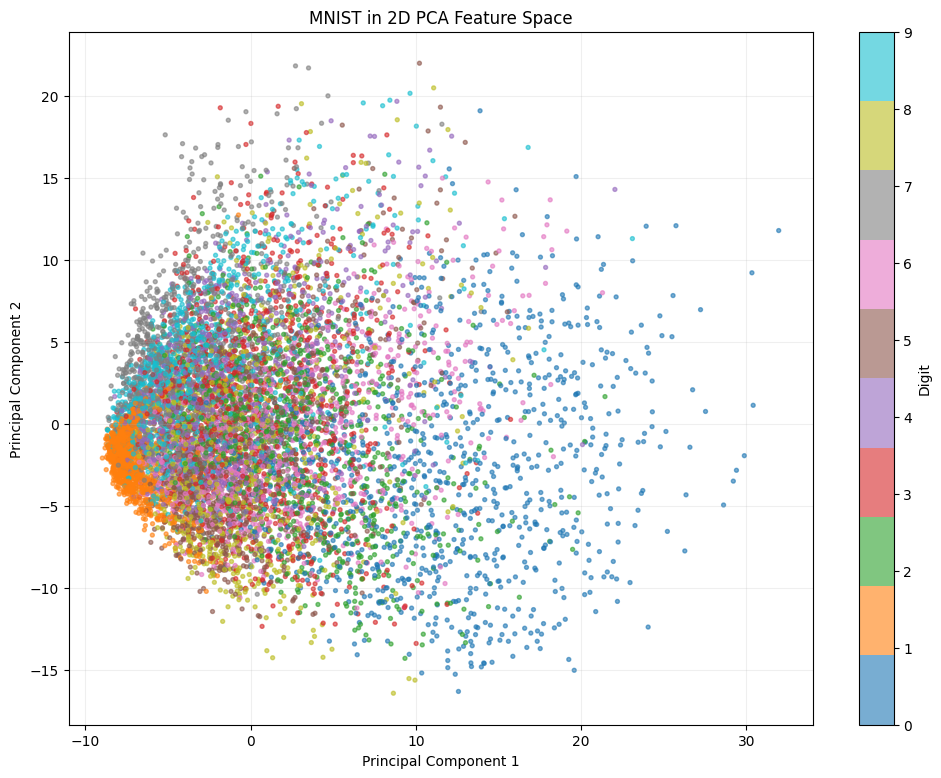

In [18]:
# ============================================================
# CELL 14: 2D PCA Visualization
# ============================================================

pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_train_2d = pca_2d.fit_transform(
    X_train_scaled
)

VISUALIZATION_SAMPLES = 10000

X_vis = X_train_2d[
    :VISUALIZATION_SAMPLES
]

y_vis = y_train[
    :VISUALIZATION_SAMPLES
]

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_vis,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "MNIST in 2D PCA Feature Space"
)

plt.grid(
    alpha=0.2
)

plt.show()

In [19]:
# ============================================================
# CELL 15: Classification using PCA Features
# ============================================================

print(
    "Training Logistic Regression "
    "using PCA features..."
)

classifier_pca = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

start_time = time.time()

classifier_pca.fit(
    X_train_pca,
    y_train
)

pca_training_time = (
    time.time() - start_time
)

y_pred_pca = (
    classifier_pca.predict(
        X_test_pca
    )
)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print(
    f"Training time: "
    f"{pca_training_time:.2f} seconds"
)

print(
    f"PCA classification accuracy: "
    f"{accuracy_pca:.4f}"
)

Training Logistic Regression using PCA features...
Training time: 80.40 seconds
PCA classification accuracy: 0.9195


In [20]:
# ============================================================
# CELL 16: Baseline Classification using Original Features
# ============================================================

print(
    "Training baseline Logistic Regression..."
)

classifier_original = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

start_time = time.time()

classifier_original.fit(
    X_train_scaled,
    y_train
)

baseline_training_time = (
    time.time() - start_time
)

y_pred_original = (
    classifier_original.predict(
        X_test_scaled
    )
)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

print(
    f"Original feature accuracy: "
    f"{accuracy_original:.4f}"
)

print(
    f"PCA feature accuracy: "
    f"{accuracy_pca:.4f}"
)

print(
    f"\nOriginal training time: "
    f"{baseline_training_time:.2f} seconds"
)

print(
    f"PCA training time: "
    f"{pca_training_time:.2f} seconds"
)

Training baseline Logistic Regression...
Original feature accuracy: 0.9163
PCA feature accuracy: 0.9195

Original training time: 62.11 seconds
PCA training time: 80.40 seconds


In [21]:
# ============================================================
# CELL 17: Classification Report
# ============================================================

print(
    "Classification Report — PCA Features"
)

print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_pca,
        digits=4
    )
)

Classification Report — PCA Features
              precision    recall  f1-score   support

           0     0.9464    0.9718    0.9589      1381
           1     0.9515    0.9708    0.9610      1575
           2     0.9174    0.8898    0.9034      1398
           3     0.9037    0.8873    0.8954      1428
           4     0.9214    0.9194    0.9204      1365
           5     0.8901    0.8717    0.8808      1263
           6     0.9345    0.9549    0.9446      1375
           7     0.9276    0.9397    0.9336      1459
           8     0.8902    0.8850    0.8876      1365
           9     0.9020    0.8936    0.8978      1391

    accuracy                         0.9195     14000
   macro avg     0.9185    0.9184    0.9184     14000
weighted avg     0.9192    0.9195    0.9193     14000



In [22]:
# ============================================================
# CELL 18: Final Results Summary
# ============================================================

summary = pd.DataFrame({

    "Metric": [
        "Original Features",
        "PCA Features",
        "Variance Retained",
        "Dimensionality Reduction",
        "Compression Ratio",
        "Reconstruction MSE",
        "Reconstruction RMSE",
        "PCA Classification Accuracy",
        "Original Classification Accuracy"
    ],

    "Value": [

        X_train_scaled.shape[1],

        X_train_pca.shape[1],

        f"{retained_variance * 100:.2f}%",

        f"{dimension_reduction:.2f}%",

        f"{compression_ratio:.2f}x",

        f"{mse:.6f}",

        f"{rmse:.6f}",

        f"{accuracy_pca:.4f}",

        f"{accuracy_original:.4f}"
    ]
})

print(
    "\nFINAL RESULTS"
)

print("=" * 60)

print(
    summary.to_string(
        index=False
    )
)


FINAL RESULTS
                          Metric    Value
               Original Features      784
                    PCA Features      330
               Variance Retained   95.01%
        Dimensionality Reduction   57.91%
               Compression Ratio    2.38x
              Reconstruction MSE 0.425057
             Reconstruction RMSE 0.651964
     PCA Classification Accuracy   0.9195
Original Classification Accuracy   0.9163
